In [1]:
# ====================================================
# 1️⃣ Setup
# ====================================================
!pip install git+https://github.com/openai/whisper.git torch torchaudio transformers accelerate evaluate -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 100.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 88.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.1 MB/s 

In [2]:
# ====================================================
# 2️⃣ Imports & Config
# ====================================================
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchaudio, json, os
from pathlib import Path
from tqdm import tqdm
import numpy as np
import pandas as pd
import evaluate
import whisper

device = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "small.en"
DATA_ROOT = Path("/kaggle/input/speechocean762")

# Load all scores once
score_data = json.load(open(DATA_ROOT / "resource" / "scores.json"))

2025-10-13 03:08:16.711954: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760324896.905001      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760324896.957342      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
# ====================================================
# 3️⃣ Load dataset splits
# ====================================================
def load_split(split_name="train"):
    split_dir = os.path.join(DATA_ROOT, split_name)
    wav_scp = os.path.join(split_dir, "wav.scp")

    wav_map = {}
    with open(wav_scp, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split(maxsplit=1)
            if len(parts) == 2:
                utt_id, wav_path = parts
                wav_map[utt_id] = os.path.join(DATA_ROOT, wav_path)

    data = []
    for utt_id, wav_path in wav_map.items():
        if utt_id in score_data:
            s = score_data[utt_id]
            target = [
                s["accuracy"],
                s["completeness"],
                s["fluency"],
                s["prosodic"],
                s["total"]
            ]
            data.append((utt_id, wav_path, target))
    return data


train_data = load_split("train")
test_data  = load_split("test")

print(f"✅ Train samples: {len(train_data)} | Test samples: {len(test_data)}")

✅ Train samples: 2500 | Test samples: 2500


In [4]:
# ====================================================
# 4️⃣ Dataset class
# ====================================================
class SpeechOceanDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        utt, wav_path, target = self.data[idx]
        wav, sr = torchaudio.load(wav_path)
        if sr != 16000:
            wav = torchaudio.functional.resample(wav, sr, 16000)

        MAX_LEN = 30 * 16000  # 30 seconds
        wav = wav[:, :MAX_LEN]
        if wav.shape[1] < MAX_LEN:
            wav = torch.nn.functional.pad(wav, (0, MAX_LEN - wav.shape[1]))

        mel = whisper.log_mel_spectrogram(wav[0])
        return mel, torch.tensor(target, dtype=torch.float32)

In [5]:
# ====================================================
# 5️⃣ Model definition
# ====================================================

import torch
import torch.nn as nn
import whisper

class WhisperRegressor(nn.Module):
    def __init__(self, model_name="small.en", freeze_n=12):
        super().__init__()
        self.whisper = whisper.load_model(model_name)

        # Freeze the first N encoder blocks to retain pretrained features
        for i, block in enumerate(self.whisper.encoder.blocks):
            if i < freeze_n:
                for p in block.parameters():
                    p.requires_grad = False

        # ✅ Correct way to get encoder hidden dimension
        dim = self.whisper.encoder.blocks[0].attn.key.weight.shape[1]

        # Regression head for 5 target metrics
        self.head = nn.Sequential(
            nn.Linear(dim, dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(dim // 2, 5)
        )

    def forward(self, mel):
        if mel.ndim == 3:
            mel = mel.squeeze(1)
        enc = self.whisper.encoder(mel.to(next(self.parameters()).device))
        pooled = enc.mean(dim=1)
        return self.head(pooled)

In [6]:
# ====================================================
# 6️⃣ Training
# ====================================================
from pathlib import Path
import numpy as np
import torch

CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

best_val_mae = float('inf')
best_model_path = None
NUM_EPOCHS = 10  # adjust as needed

In [7]:
train_ds = SpeechOceanDataset(train_data)
test_ds = SpeechOceanDataset(test_data)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False) 

model = WhisperRegressor(model_name=MODEL_NAME).to(device) 
opt = torch.optim.AdamW(model.parameters(), lr=1e-5) 
loss_fn = nn.L1Loss()

100%|███████████████████████████████████████| 461M/461M [04:36<00:00, 1.75MiB/s]


In [8]:
for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0.0

    for mel, target in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
        mel, target = mel.to(device), target.to(device)
        opt.zero_grad()
        pred = model(mel)
        loss = loss_fn(pred, target)
        loss.backward()
        opt.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    preds, trues = [], []

    with torch.no_grad():
        for mel, target in test_loader:
            mel, target = mel.to(device), target.to(device)
            pred = model(mel)
            loss = loss_fn(pred, target)
            val_loss += loss.item()
            preds.append(pred.cpu().numpy())
            trues.append(target.cpu().numpy())

    avg_val_loss = val_loss / len(test_loader)
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    mae_total = np.mean(np.abs(preds[:, 4] - trues[:, 4]))  # total score MAE

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | Val MAE (total): {mae_total:.4f}")

    # --- Save checkpoint ---
    checkpoint_path = CHECKPOINT_DIR / f"whisper_epoch{epoch+1}.pt"
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': opt.state_dict(),
        'train_loss': avg_train_loss,
        'val_loss': avg_val_loss,
        'val_mae_total': mae_total,
    }, checkpoint_path)
    print(f"✅ Saved checkpoint: {checkpoint_path.name}")

    # --- Keep only best model ---
    if mae_total < best_val_mae:
        best_val_mae = mae_total
        best_model_path = checkpoint_path
        print(f"🏆 New best model (MAE total={mae_total:.4f}) saved at {best_model_path.name}")
    else:
        checkpoint_path.unlink(missing_ok=True)

print(f"\n✅ Training complete. Best model: {best_model_path.name} (MAE total={best_val_mae:.4f})")

Epoch 1/10: 100%|██████████| 313/313 [09:05<00:00,  1.74s/it]


Epoch 1/10 | Train Loss: 6.0990 | Val Loss: 3.2931 | Val MAE (total): 2.0608
✅ Saved checkpoint: whisper_epoch1.pt
🏆 New best model (MAE total=2.0608) saved at whisper_epoch1.pt


Epoch 2/10: 100%|██████████| 313/313 [08:32<00:00,  1.64s/it]


Epoch 2/10 | Train Loss: 1.5839 | Val Loss: 0.8419 | Val MAE (total): 1.0177
✅ Saved checkpoint: whisper_epoch2.pt
🏆 New best model (MAE total=1.0177) saved at whisper_epoch2.pt


Epoch 3/10: 100%|██████████| 313/313 [08:32<00:00,  1.64s/it]


...

Epoch 8/10 | Train Loss: 0.8112 | Val Loss: 0.7203 | Val MAE (total): 0.8882
✅ Saved checkpoint: whisper_epoch8.pt


Epoch 9/10: 100%|██████████| 313/313 [08:35<00:00,  1.65s/it]


Epoch 9/10 | Train Loss: 0.7967 | Val Loss: 0.7155 | Val MAE (total): 0.8865
✅ Saved checkpoint: whisper_epoch9.pt


Epoch 10/10: 100%|██████████| 313/313 [08:35<00:00,  1.65s/it]


Epoch 10/10 | Train Loss: 0.7769 | Val Loss: 0.6772 | Val MAE (total): 0.8372
✅ Saved checkpoint: whisper_epoch10.pt
🏆 New best model (MAE total=0.8372) saved at whisper_epoch10.pt

✅ Training complete. Best model: whisper_epoch10.pt (MAE total=0.8372)


In [9]:
# Optional: save final best model under a fixed name for inference
final_model_path = CHECKPOINT_DIR / "whisper_finetune_final.pth"
torch.save(model.state_dict(), final_model_path)
print(f"💾 Final model saved to {final_model_path}")

💾 Final model saved to checkpoints/whisper_finetune_final.pth


In [10]:
# ====================================================
# 7️⃣ Evaluation
# ====================================================
model.eval()
metric_corr = evaluate.load("pearsonr")

y_true, y_pred = [], []
with torch.no_grad():
    for mel, y in tqdm(test_loader, desc="Evaluating"):
        mel, y = mel.to(device), y.to(device)
        preds = model(mel)
        y_true.append(y.cpu().numpy())
        y_pred.append(preds.cpu().numpy())

y_true, y_pred = np.vstack(y_true), np.vstack(y_pred)
mae = np.mean(np.abs(y_true - y_pred), axis=0)
corr = [metric_corr.compute(predictions=y_pred[:, i], references=y_true[:, i])["pearsonr"] for i in range(5)]

results = pd.DataFrame({
    "metric": ["accuracy", "completeness", "fluency", "prosodic", "total"],
    "MAE": mae,
    "Corr": corr
})

results

Evaluating: 100%|██████████| 313/313 [03:14<00:00,  1.61it/s]


,metric,MAE,Corr
0,accuracy,0.850924,0.637193
1,completeness,0.228523,0.114535
2,fluency,0.716437,0.716196
3,prosodic,0.746010,0.698759
4,total,0.837226,0.651921


In [11]:
# ====================================================
# 🔍 Diagnostic: data alignment & score distribution
# ====================================================

import numpy as np
import json
from collections import Counter

In [12]:
# 1️⃣ Basic integrity check
print("Train samples:", len(train_data))
print("Test samples :", len(test_data))

# Check overlap between audio IDs and score entries
score_ids = set(score_data.keys())
train_ids = set([x[0] for x in train_data])
test_ids = set([x[0] for x in test_data])
print("Train overlap with scores:", len(train_ids & score_ids))
print("Test overlap with scores :", len(test_ids & score_ids))

Train samples: 2500
Test samples : 2500
Train overlap with scores: 2500
Test overlap with scores : 2500


In [13]:
# 2️⃣ Distribution of each score type
accs, comps, flus, pros, tots = [], [], [], [], []

for s in score_data.values():
    accs.append(s["accuracy"])
    comps.append(s["completeness"])
    flus.append(s["fluency"])
    pros.append(s["prosodic"])
    tots.append(s["total"])

def describe(arr, name):
    arr = np.array(arr)
    print(f"{name:<12} | min={arr.min():.3f} max={arr.max():.3f} mean={arr.mean():.3f} std={arr.std():.3f}")

print("\n--- Score Distributions ---")
describe(accs, "accuracy")
describe(comps, "completeness")
describe(flus, "fluency")
describe(pros, "prosodic")
describe(tots, "total")


--- Score Distributions ---
accuracy     | min=1.000 max=10.000 mean=7.657 std=1.619
completeness | min=0.000 max=10.000 mean=9.980 std=0.370
fluency      | min=0.000 max=10.000 mean=7.784 std=1.492
prosodic     | min=0.000 max=10.000 mean=7.462 std=1.469
total        | min=0.000 max=10.000 mean=7.222 std=1.610


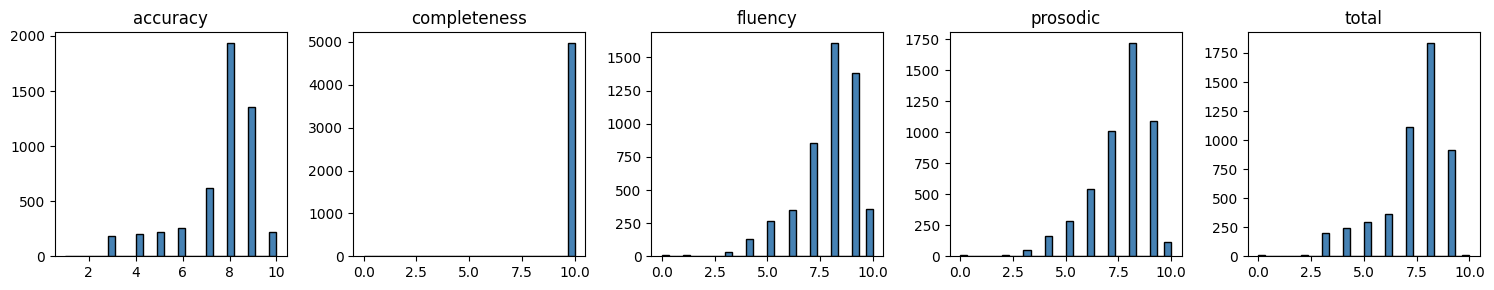

In [14]:
# 3️⃣ Optional: visualize (if you want histograms)
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, arr, name in zip(axes, [accs, comps, flus, pros, tots],
                         ["accuracy", "completeness", "fluency", "prosodic", "total"]):
    ax.hist(arr, bins=30, color="steelblue", edgecolor="black")
    ax.set_title(name)
plt.tight_layout()
plt.show()